TBG Model initialized with:
  Twist angle: 0.94°
  Number of Q points: 250
  Hamiltonian size: 500 x 500
  Fermi velocity: 0.6829
  Hopping parameters: u=0.08, u'=0.11

Diagonalizing along K -> Γ -> M -> K' path (with band tracking)...


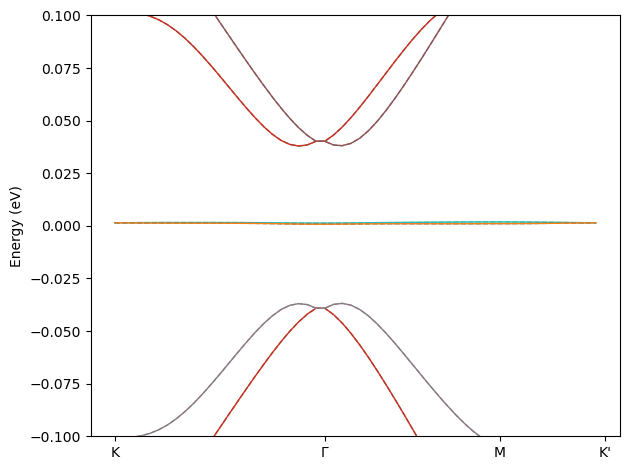

Band structure computed for 56 k-points
Number of bands: 500
Energy range: -2.234 to 2.234 eV


In [1]:
import numpy as np
from numpy.linalg import eigh, norm
import matplotlib.pyplot as plt

def R(x):
    return np.array([
        [np.cos(x), -np.sin(x)],
        [np.sin(x),  np.cos(x)]
    ])

# 2x2 Identity matrix
I = np.identity(2)

def Et(theta, theta_s, e, delta):
    return R(-theta_s) @ np.array(([e, 0], [0, -delta*e])) @ R(theta_s) + np.array(([0, -theta], [theta, 0]))


# Q is a vector in reciprocal lattice with extra
# Now we aim to extract ijl Q=i*b1+j*b2-l*q0
def recover_ij_from_Q(Q, b, q0, rtol=1e-8, atol=1e-6):

    B = np.column_stack((b[0], b[1]))  # 2x2 matrix [b1 b2]
    Binv = np.linalg.inv(B)

    ijl = []  
    for row in Q:  #
        kx, ky, l = row
        k = np.array([kx, ky], dtype=float)
        l = int(round(l))
        v = Binv @ (k + l * q0)  # continuous (i,j)
        ij = np.rint(v).astype(int)  ## Obtain integer ij 
   
        ijl.append((ij[0], ij[1], l))
    return ijl

# Find all possible pairs G in reciporal lattice s.t
#  G=-G; Here we run through G,-G and -G, G
def find_opposite_G_pairs(Q, b, q, rtol=1e-8, atol=1e-6):
    q0 = q[0]
    ijl = recover_ij_from_Q(Q, b, q0, rtol=rtol, atol=atol)

    buckets = {}  # A python Dictionary object 
    for idx, (i, j, l) in enumerate(ijl):
        buckets.setdefault((i, j,l), idx);  ## {(i,j,l),idx} is the list
    ## Code is bind ijl with the index in Q.
    pairs = [];
    for (i, j,l), idx_a in buckets.items():  ## View List Elements
        key_a, key_b = (i, j,l), (-i, -j,l)
        
        if key_b in buckets:  # equivalent to: if key_b in buckets.keys():
                              
            idx_b = buckets[key_b]
            pairs.append((idx_a, idx_b))

    return pairs

def _perm_from_overlap(U_prev, U_curr):

    O = np.abs(U_prev.conj().T @ U_curr)  # (nband, nband)
    n = O.shape[0]
    perm = [-1]*n
    used_cols = set()

    for _ in range(n):
        i, j = divmod(int(O.argmax()), n)
        # find a column not yet used
        while j in used_cols:
            O[i, j] = -1.0
            i, j = divmod(int(O.argmax()), n)
        perm[i] = j
        used_cols.add(j)
        O[i, :] = -1.0
        O[:, j] = -1.0
    return np.array(perm, dtype=int)

class TBGModel():
    
    def __init__(self, theta, phi, epsilon,  # empirical (deg, deg, strain)
                 a=0.246, beta=3.14, delta=0.16,  # graphene
                 vf=1.3, u=0.08, up=0.11, cut=6):  # continuum
        # Convert degrees to radians
        theta = theta*np.pi/180
        phi = phi*np.pi/180

        # Empirical
        self.theta = theta
        self.phi = phi
        self.epsilon = epsilon

        # Graphene params
        self.a = a
        self.beta = beta
        self.delta = delta
        self.A = np.sqrt(3)*self.beta/2/a  # gauge connection

        # Continuum params
        self.v = vf*2.1354*a      # vf = 1.3 used in many works
        self.v3 = np.sqrt(3)*a*0.32/2
        self.v4 = np.sqrt(3)*a*0.044/2
        self.gamma1 = 0.4
        self.Dp = 0.05

        self.omega = np.exp(1j*2*np.pi/3)
        self.u = u
        self.up = up

        # Monolayer K vectors
        k_d = 4*np.pi/3/a
        k1 = np.array([k_d, 0.0])
        k2 = np.array([np.cos(2*np.pi/3)*k_d, np.sin(2*np.pi/3)*k_d])
        k3 = -np.array([np.cos(np.pi/3)*k_d, np.sin(np.pi/3)*k_d])

        # Strained moiré reciprocal vectors
        q1 = Et(theta, phi, epsilon, delta) @ k1
        q2 = Et(theta, phi, epsilon, delta) @ k2
        q3 = Et(theta, phi, epsilon, delta) @ k3
        q = np.array([q1, q2, q3])
        self.q = q
        k_theta = np.max([norm(q1), norm(q2), norm(q3)])
        self.k_theta = k_theta

        # Q-lattice basis
        b1 = q[1] - q[2]
        b2 = q[0] - q[2]
        b3 = q[1] - q[0]
        b = np.array([b1, b2, b3])
        self.b = b

        # Generate Q lattice
        Q = []
        for i in range(-100, 100):
            for j in range(-100, 100):
                for l in (0, 1):
                    kvec = np.array([i, j, 0.0]) @ b - l*q[0]
                    if norm(kvec) <= np.sqrt(3)*k_theta*cut:
                        Q.append(np.array([kvec[0], kvec[1], l], dtype=float))
        self.Q = np.array(Q, dtype=float)
        self.Nq = len(self.Q)

        # Nearest neighbors on the Q lattice
        self.Q_nn = {}
        Qxy = np.round(self.Q[:, :2], 3)
        Qlist = Qxy.tolist()
        for idx in range(self.Nq):
            nbrs = []
            for j in range(len(q)):
                tgt = np.round(self.Q[idx, :2] + q[j], 3)
                try:
                    jidx = Qlist.index(tgt.tolist())
                    nbrs.append([jidx, j])
                except ValueError:
                    pass
            self.Q_nn[idx] = nbrs

    def find_opposite_G_pairs(self, rtol=1e-8, atol=1e-6):
        return find_opposite_G_pairs(self.Q, self.b, self.q, rtol=rtol, atol=atol)

    def __post_init_deltas(self):
        # Nearest-neighbor A→B real-space vectors (a = lattice constant, 0.246 nm)
        a = self.a
        self.delta_AB = np.array([
            [0.0,          a/np.sqrt(3)],       # δ1
            [-a/2.0,      -a/(2*np.sqrt(3))],   # δ2
            [ a/2.0,      -a/(2*np.sqrt(3))],   # δ3
        ])

    def phi_l(self, q, l, Layer=0, xi=1):
        if not hasattr(self, "delta_AB"):
            self.__post_init_deltas()
        q = np.asarray(q, dtype=float)
        was_1d = (q.ndim == 1)
        q = q.reshape(-1, 2)

        w = self.omega
        l = int(l) % 3
        t = 2*int(Layer) - 1
        M = Et(t*xi*self.theta/2, self.phi, t*xi*self.epsilon/2, self.delta)
        A = np.eye(2) + M
        ### 
        delta1, delta2, delta3=self.delta_AB[0],self.delta_AB[1],self.delta_AB[2];
        a1=delta3-delta1; a2=delta2-delta1; 
        ###
        tau=delta1; 
        m=0; n=0;
        first=tau+m*a1+n*a2;
        second=tau+n*a1+(1-m-n)*a2;
        third=tau+(1-m-n)*a1+m*a2;
        
        ###
        d1, d2, d3 = (A.T @ first,
                      A.T @ second,
                      A.T @ third)

        val = (np.exp(-1j * (q @ d1)) +
               (w**l)    * np.exp(-1j * (q @ d2)) +
               (w**(2*l))* np.exp(-1j * (q @ d3)))
        return val[0] if was_1d else val

    def gen_ham(self, kx, ky, xi=1):
        
        k = np.array([kx, ky], dtype=float)
        #
        U1 = np.array([[self.u, self.up],
                       [self.up, self.u]], dtype=complex)
        #
        U2 = np.array([[self.u, self.up*self.omega**(-xi)],
                       [self.up*self.omega**( xi), self.u]], dtype=complex)
        #
        U3 = np.array([[self.u, self.up*self.omega**( xi)],
                       [self.up*self.omega**(-xi), self.u]], dtype=complex)
        #
        ham = np.zeros((2*self.Nq, 2*self.Nq), dtype=complex)
        #
        for i in range(self.Nq):
            t = self.Q[i, 2]
            l = np.sign(2*t - 1)  # +1 for layer 1, -1 for layer 0
            M = Et(l*xi*self.theta/2, self.phi, l*xi*self.epsilon/2, self.delta)
            E = (M + M.T)/2
            exx, eyy, exy = E[0, 0], E[1, 1], E[0, 1]
            kj = (I + M) @ (k + self.Q[i, :2] + xi*self.A*np.array([exx - eyy, -2*exy]))
            km = xi*kj[0] - 1j*kj[1]

            # Diagonal blocks
            ham[2*i, 2*i+1] = -self.v * km

            # Off-diagonal moiré couplings
            for (j, p) in self.Q_nn[i]:
                ham[2*i:2*i+2, 2*j:2*j+2] = (p == 0)*U1 + (p == 1)*U2 + (p == 2)*U3

        return ham + ham.conj().T

    def _build_kpath(self, res):
        """K → Γ → M → K' path (vectors in units of moiré reciprocal)."""
        l1 = int(res)                 # K -> Γ
        l2 = int(np.sqrt(3)*res/2)    # Γ -> M
        l3 = int(res/2)               # M -> K'
        kpath = []
        for i in np.linspace(0, 1, l1):
            kpath.append(i*(self.q[0] + self.q[1]))
        for i in np.linspace(0, 1, l2):
            kpath.append(self.q[0] + self.q[1] + i*(-self.q[0]/2 - self.q[1]))
        for i in np.linspace(0, 1, l3):
            kpath.append(self.q[0]/2 + i*self.q[0]/2)
        return np.array(kpath), l1, l2, l3

    def solve_along_path(self, res=24, plot_it=True, return_eigenvectors=False, track_bands=True, ylim=(0.03, 0.06)):
        """
        Diagonalize along K→Γ→M→K' with optional band tracking.
        """
        kpath, l1, l2, l3 = self._build_kpath(res)

        evals_m, evals_p = [], []
        evecs_m, evecs_p = [], []

        U_prev_m = U_prev_p = None
        for kx, ky in kpath:
            val_m, vec_m = eigh(self.gen_ham(kx, ky, +1))
            val_p, vec_p = eigh(self.gen_ham(kx, ky, +1))

            if track_bands and U_prev_m is not None:
                perm_m = _perm_from_overlap(U_prev_m, vec_m)
                val_m = val_m[perm_m]; vec_m = vec_m[:, perm_m]
                perm_p = _perm_from_overlap(U_prev_p, vec_p)
                val_p = val_p[perm_p]; vec_p = vec_p[:, perm_p]

            U_prev_m, U_prev_p = vec_m, vec_p
            evals_m.append(val_m); evals_p.append(val_p)
            if return_eigenvectors:
                evecs_m.append(vec_m); evecs_p.append(vec_p)

        evals_m = np.vstack(evals_m)
        evals_p = np.vstack(evals_p)

        if plot_it:
            plt.figure(1); plt.clf()
            nband = evals_m.shape[1]
            for i in range(nband):
                plt.plot(evals_m[:, i], linestyle='dashed', linewidth=1.0)
                plt.plot(evals_p[:, i], linewidth=1.0)
            if ylim is not None:
                plt.ylim(*ylim)
            plt.xticks([0, l1, l1+l2, l1+l2+l3], ['K', r'$\Gamma$', 'M', "K'"])
            plt.ylabel('Energy (eV)')
            plt.tight_layout()
            plt.show()

        if return_eigenvectors:
            return evals_m, evals_p, np.array(evecs_m), np.array(evecs_p), kpath
        else:
            return evals_m, evals_p, kpath

# -------- Example usage --------
if __name__ == "__main__":
    magic_angle = 0.94  # degrees
    phi = 0.0            # strain angle
    epsilon = 0.0        # strain magnitude

    tbg = TBGModel(magic_angle, phi, epsilon)

    print(f"TBG Model initialized with:")
    print(f"  Twist angle: {magic_angle}°")
    print(f"  Number of Q points: {tbg.Nq}")
    print(f"  Hamiltonian size: {2*tbg.Nq} x {2*tbg.Nq}")
    print(f"  Fermi velocity: {tbg.v:.4f}")
    print(f"  Hopping parameters: u={tbg.u}, u'={tbg.up}")

    print("\nDiagonalizing along K -> Γ -> M -> K' path (with band tracking)...")
    # Increase res for smoother curves if desired, e.g., res=64 or 96
    evals_m, evals_p, kpath = tbg.solve_along_path(res=24, track_bands=True, ylim=(-0.1,0.1))

    print(f"Band structure computed for {len(kpath)} k-points")
    print(f"Number of bands: {evals_m.shape[1]}")
    print(f"Energy range: {evals_m.min():.3f} to {evals_m.max():.3f} eV")


In [2]:
import numpy as np
from numpy.linalg import eigh

# ------------------------------------------------------------
# Optional: smooth band tracker (use yours if you already have it)
# ------------------------------------------------------------
try:
    SmoothTracker
except NameError:
    SmoothTracker = None


# ------------------------------------------------------------
# Utility: pick a subspace of band indices (optional)
# ------------------------------------------------------------
def pick_subspace_indices(e_plus, e_minus, subspace_dim, mode="center"):
    """
    Return band indices idx (length=subspace_dim) selecting a stable subspace.
    mode="center": centered contiguous window in the sorted eigenvalue list.
    mode="closest_to_zero": smallest |e_plus|+|e_minus| (less stable at crossings without tracking).
    """
    e_plus  = np.asarray(e_plus, float)
    e_minus = np.asarray(e_minus, float)
    M = e_plus.size
    if subspace_dim is None:
        return np.arange(M, dtype=int)
    if subspace_dim > M:
        raise ValueError(f"subspace_dim={subspace_dim} > M={M}")

    if mode == "center":
        start = (M - subspace_dim) // 2
        return np.arange(start, start + subspace_dim, dtype=int)

    if mode == "closest_to_zero":
        score = np.abs(e_plus) + np.abs(e_minus)
        idx = np.argsort(score)[:subspace_dim]
        # deterministic ordering
        return idx[np.argsort(e_plus[idx])]

    raise ValueError("mode must be 'center' or 'closest_to_zero'")


# ------------------------------------------------------------
# CORE: compute FULL Lambda (and optionally a subspace block)
# ------------------------------------------------------------
def compute_Lambda(
    tbg, k, *,
    Layer=0, Sym=0,
    pairs=None,
    xi=+1,
    COM=None,
    tracker_plus=None,
    tracker_minus=None,
    use_tracking=False,
    subspace_dim=None,
    subspace_mode="center",
):
    """
    Compute pairing form-factor matrix Lambda at momentum k.

    - FULL Lambda: set subspace_dim=None  -> returns (M,M) matrix (M = 2*Nq bands)
    - Subspace Lambda: set subspace_dim=int -> returns (subspace_dim, subspace_dim) matrix

    Convention matches your code:
        Lambda = V_plus^T (phases * V_minus)
    (transpose, NOT Hermitian conjugate)

    Returns:
        Lambda_out, e_plus_out, e_minus_out, idx_out, tracker_plus, tracker_minus

    where idx_out is the band-index subset used (full: 0..M-1).
    """
    k = np.asarray(k, float).reshape(2,)
    kx, ky = float(k[0]), float(k[1])

    if pairs is None:
        pairs = tbg.find_opposite_G_pairs()
        
    #COM_TUNE
    Gamma=tbg.q[0] + tbg.q[1];
    M=0.5 * tbg.q[0]
    tune=5.5*2;
    if COM is None:   
        COM = Gamma+ (M-Gamma)/10*tune;
    else:
        COM = np.asarray(COM, float).reshape(2,)

    # Build H(k+COM) and H(-k+COM)
    H_plus  = np.asarray(tbg.gen_ham(kx + COM[0],  ky + COM[1], xi=xi))
    H_minus = np.asarray(tbg.gen_ham(-kx + COM[0], -ky + COM[1], xi=xi))

    e_plus,  U_plus  = eigh(H_plus)
    e_minus, U_minus = eigh(H_minus)

    # Optional smooth tracking (highly recommended if you later slice subspaces)
    if use_tracking:
        if SmoothTracker is None:
            raise RuntimeError("SmoothTracker not found; define it or set use_tracking=False.")
        if tracker_plus is None:
            tracker_plus = SmoothTracker()
        if tracker_minus is None:
            tracker_minus = SmoothTracker()
        e_plus,  U_plus  = tracker_plus.align(e_plus,  U_plus)
        e_minus, U_minus = tracker_minus.align(e_minus, U_minus)

    M = U_plus.shape[1]

    # Choose band subset (full if subspace_dim is None)
    idx = pick_subspace_indices(e_plus, e_minus, subspace_dim, mode=subspace_mode)

    e_plus_out  = e_plus[idx]
    e_minus_out = e_minus[idx]
    U_plus_sub  = U_plus[:, idx]   # (2Nq, nb)
    U_minus_sub = U_minus[:, idx]  # (2Nq, nb)
    nb = idx.size

    # Restrict G-pairs to the chosen Layer
    pairs_L = [(a, b) for (a, b) in pairs
               if int(round(tbg.Q[a, 2])) == int(Layer)
               and int(round(tbg.Q[b, 2])) == int(Layer)]

    idx_a = np.fromiter((a for a, _ in pairs_L), dtype=int)
    idx_b = np.fromiter((b for _, b in pairs_L), dtype=int)

    # Your convention: plus uses A-row of idx_a, minus uses B-row of idx_b
    rows_a = 2*idx_a + 0
    rows_b = 2*idx_b + 1

    V_plus  = np.take(U_plus_sub,  rows_a, axis=0)  # (P, nb)
    V_minus = np.take(U_minus_sub, rows_b, axis=0)  # (P, nb)

    # Phases: need q = (Layer*q0 + Q[idx_a]) + k
    q0 = np.asarray(tbg.q[0], float).reshape(2,)
    Gs = int(Layer) * q0 + np.asarray(tbg.Q[idx_a, :2], float)  # (P,2)

    phases = np.conj(np.asarray(tbg.phi_l(Gs + k[None, :], Sym, int(Layer), xi=xi))).reshape(-1)
    # phases shape: (P,)

    P = phases.size
    if V_plus.shape != (P, nb) or V_minus.shape != (P, nb):
        raise ValueError(f"Shape mismatch: phases {phases.shape}, V_plus {V_plus.shape}, V_minus {V_minus.shape}")

    # FULL (or subspace) Lambda in your pp convention (transpose)
    Lambda = V_plus.T @ (phases[:, None] * V_minus)  # (nb, nb)

    return Lambda, e_plus_out, e_minus_out, idx, tracker_plus, tracker_minus


# ------------------------------------------------------------
# Example usage
# ------------------------------------------------------------
if __name__ == "__main__":
    # assumes you already created: tbg = TBGModel(...)
    pairs = tbg.find_opposite_G_pairs()

    k = np.array([0.001, 0.002])

    # ---- full Lambda (huge!) ----
    L_full, ep_full, em_full, idx_full, _, _ = compute_Lambda(
        tbg, k, Layer=0, Sym=0, pairs=pairs,
        subspace_dim=None,   # full
        use_tracking=False
    )
    print("FULL Lambda shape:", L_full.shape)

    # ---- subspace Lambda (recommended) ----
    L20, ep20, em20, idx20, _, _ = compute_Lambda(
        tbg, k, Layer=0, Sym=0, pairs=pairs,
        subspace_dim=20, subspace_mode="center",
        use_tracking=False
    )
    print("SUBSPACE Lambda shape:", L20.shape)
    print("band indices used:", idx20)


FULL Lambda shape: (500, 500)
SUBSPACE Lambda shape: (20, 20)
band indices used: [240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257
 258 259]


In [3]:
import numpy as np
from numpy.linalg import eigh
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional


class SmoothTracker:
    
    ## Important. Remember Prevoius State
    def __init__(self, eps_deg: float = 1e-5):
        self.U_prev: Optional[np.ndarray] = None
        self.e_prev: Optional[np.ndarray] = None
        self.eps_deg = eps_deg

    @staticmethod
    def _hungarian_match(U_prev, U_curr):
        O = np.abs(U_prev.conj().T @ U_curr)
        rows, cols = linear_sum_assignment(1.0 - O)
        # linear_sum_assignment minimize the cost function \sum_i 1- O_{i,\pi(i)}
        # So one can find correct cols.
        return cols
    
    
    def _deg_blocks(self, e):
        e = np.asarray(e, float)
        n = e.size
        if n == 0: return []
        blocks = []
        i = 0
        while i < n:
            j = i + 1
            while j < n and abs(e[j] - e[i]) <= self.eps_deg * max(1.0, abs(e[i])):
                j += 1
            blocks.append(np.arange(i, j))
            i = j
        return blocks

    def align(self, e_curr, U_curr):
        #
        if self.U_prev is None:
            e = np.asarray(e_curr).copy()
            U = np.asarray(U_curr, complex).copy()
            ##
            for b in range(U.shape[1]):
                col = U[:, b]
                m = np.argmax(np.abs(col))
                ###
                if np.abs(col[m]) > 0:
                    phase=col[m] / np.abs(col[m]);
                    U[:, b] /= phase;
                ###
            self.e_prev, self.U_prev = e, U
            return e, U

        # 1) match bands
        
        # return permutation index
        perm = self._hungarian_match(self.U_prev, U_curr) 
        e = np.asarray(e_curr)[perm]  ## Perform Permuations.
        U = np.asarray(U_curr, complex)[:, perm]

        # 2) align within degenerate blocks
        for blk in self._deg_blocks(e):
            if np.size(blk) == 1:
                t = int(blk[0])                           # global band index
                ov = self.U_prev[:, t].conj().T @ U[:, t] # complex overlap
                if np.abs(ov) > 0:
                    U[:, t] /= ov / np.abs(ov)            # make overlap real-positive
                continue

            Up = self.U_prev[:, blk]  # (dim, m)
            Uc = U[:, blk]            # (dim, m)
            M = Up.conj().T @ Uc
            L, _, Rh = np.linalg.svd(M, full_matrices=False)
            W = Rh.conj().T @ L.conj().T
            U[:, blk] = Uc @ W
            # parallel-transport (positive-real overlap)
            
            for t in range(len(blk)):
                ov = Up[:, t].conj().T @ U[:, blk[t]]
                if ov != 0:
                    U[:, blk[t]] /= ov/abs(ov)

        self.e_prev, self.U_prev = e, U
        return e, U

def serpentine_masked_indices(mask):
    H, W = mask.shape
    for i in range(H):
        js = np.flatnonzero(mask[i])
        if i % 2: js = js[::-1]
        for j in js:
            yield i, j

def hex_bz_mesh(b1, b2, N=10,mode ='six'):
    tol=1e-12
    b1 = np.asarray(b1, float); b2 = np.asarray(b2, float)
    B = np.column_stack([b1, b2]); BinvT = np.linalg.inv(B.T)
    b1sq, b2sq = np.dot(b1, b1), np.dot(b2, b2)

    rng = np.arange(-N, N + 1)
    I, J = np.meshgrid(rng, rng, indexing='ij')
    c1 = I / N; c2 = J / N

    if mode == 'six':
        mask = (np.abs(c1) <= 1 + tol) & (np.abs(c2) <= 1 + tol) & (np.abs(c1 + c2) <= 1 + tol)
    elif mode == 'none':
        mask = (np.abs(c1) <  1 - tol) & (np.abs(c2) <  1 - tol) & (np.abs(c1 + c2) <  1 - tol)
    elif mode == 'three_alternating':
        # keep:  c1 = -1, c2 = -1, c1+c2 = +1
        # drop:  c1 = +1, c2 = +1, c1+c2 = -1  (strict)
        mask = (c1 >= -1 - tol) & (c1 <  1 - tol) & \
               (c2 >= -1 - tol) & (c2 <  1 - tol) & \
               (c1 + c2 <= 1 + tol) & (c1 + c2 > -1 + tol)
        # => all 6 vertices are excluded (each sits on one dropped edge)
    elif mode == 'three_consecutive':
        # keep:  c1 = -1, c2 = -1, c1+c2 = -1  (inclusive)
        # drop:  c1 = +1, c2 = +1, c1+c2 = +1  (strict)
        mask = (c1 >= -1 - tol) & (c2 >= -1 - tol) & (c1 + c2 >= -1 - tol) & \
               (c1 <  1 - tol) & (c2 <  1 - tol) & (c1 + c2 <  1 - tol)
        # => includes exactly two vertices: (-1,0) and (0,-1)
    else:
        raise ValueError("mode must be 'six', 'none', 'three_alternating', or 'three_consecutive'")

    c1v = c1[mask].ravel()
    c2v = c2[mask].ravel()
    s = np.vstack([0.5 * b1sq * c1v, 0.5 * b2sq * c2v])  # [k·b1, k·b2]
    kpts = (BinvT @ s).T
    idx_map = -np.ones(mask.shape, dtype=int)
    idx_map[mask] = np.arange(mask.sum(), dtype=int)
    return kpts, mask, idx_map

import os
import numpy as np
from numpy.linalg import norm, eigh

#
OUT_DIR = "lambda_dump"
 
# 
def ensure_dir(path):
    if not os.path.isdir(path):
        os.makedirs(path, exist_ok=True)

def save_lambda_npz(basepath, k, layer, sym, Lambda, evals_plus, evals_minus):
    np.savez_compressed(basepath + ".npz",k=np.asarray(k, float),
        layer=int(layer),sym=int(sym),Lambda=Lambda,
        evals_plus=np.asarray(evals_plus, float),
        evals_minus=np.asarray(evals_minus, float),
    )

def save_lambda_csv_pair(basepath, Lambda):
    # CSVs for real/imag separately (compact and easy to reload)
    np.savetxt(basepath + "_real.csv", np.real(Lambda), delimiter=",")
    np.savetxt(basepath + "_imag.csv", np.imag(Lambda), delimiter=",")

def save_lambda_npz(basepath, k, layer, sym, Lambda, evals_plus, evals_minus, band_idx):
    """
    Save ONE (k, layer, sym) block.
    Lambda is either full (M,M) or subspace (nb,nb) depending on what you computed.
    """
    np.savez_compressed(
        basepath + ".npz",
        k=np.asarray(k, float),
        layer=int(layer),
        sym=int(sym),
        Lambda=np.asarray(Lambda),
        evals_plus=np.asarray(evals_plus, float),
        evals_minus=np.asarray(evals_minus, float),
        band_idx=np.asarray(band_idx, int),
    )

# ------------------------------------------------------------
# Traversal helpers (assume you already have these in your codebase)
#   - hex_bz_mesh(b1,b2,N,mode='six') -> (kpts_cart, mask, idx_map)
#   - serpentine_masked_indices(mask) -> iterator over (i,j)
# ------------------------------------------------------------

# ------------------------------------------------------------
# Main dumper (FULL Lambda or SUBSPACE Lambda)
# ------------------------------------------------------------
def dump_all_Lambdas(
    tbg, b1, b2, N1, *,
    out_dir="lambda_dump",
    syms=(0, 1, 2),
    layers=(0, 1),
    xi=+1,
    eps_deg=1e-5,
    use_tracking=False,               # True -> use SmoothTracker
    subspace_dim=None,                # None -> FULL Lambda, int -> save only (subspace_dim, subspace_dim)
    subspace_mode="center",           # "center" or "closest_to_zero"
):
    """
    Loop over BZ mesh k-points (serpentine order), compute Λ(k) and save to disk.

    - If subspace_dim is None: saves FULL Lambda (very large: (2*Nq)x(2*Nq)).
    - If subspace_dim is int: saves ONLY the subspace block (subspace_dim x subspace_dim).

    Requires:
      - compute_Lambda(tbg, k, Layer=..., Sym=..., pairs=..., xi=..., COM=...,
                       tracker_plus=..., tracker_minus=..., use_tracking=...,
                       subspace_dim=..., subspace_mode=...)
      - SmoothTracker class (if use_tracking=True)
      - hex_bz_mesh + serpentine_masked_indices
    """
    ensure_dir(out_dir)
    pairs = tbg.find_opposite_G_pairs()

    # k-mesh + serpentine order
    kpts_cart, mask, idx_map = hex_bz_mesh(b1, b2, N1, mode="six")
    order = [idx_map[i, j] for i, j in serpentine_masked_indices(mask)]

    # write index of k points
    index_path = os.path.join(out_dir, "k_index.csv")
    with open(index_path, "w") as fidx:
        fidx.write("k_index,kx,ky\n")
        for new_i, flat_i in enumerate(order):
            k = kpts_cart[flat_i]
            fidx.write(f"{new_i},{k[0]},{k[1]}\n")

    # trackers (persist across k for smoothness)
    trackers = {}
    if use_tracking:
        if SmoothTracker is None:
            raise RuntimeError("use_tracking=True but SmoothTracker is not defined/imported.")
        for layer in layers:
            for sym in syms:
                trackers[(layer, sym)] = (SmoothTracker(eps_deg=eps_deg),
                                          SmoothTracker(eps_deg=eps_deg))

    # summary
    summary_path = os.path.join(out_dir, "summary.csv")
    with open(summary_path, "w") as fs:
        fs.write("k_index,layer,sym,nb,trace_abs,max_abs\n")

        for new_i, flat_i in enumerate(order):
            k = np.asarray(kpts_cart[flat_i], float).reshape(2,)

            for layer in layers:
                for sym in syms:
                    if use_tracking:
                        tr_p, tr_m = trackers[(layer, sym)]
                    else:
                        tr_p = tr_m = None

                    Lambda, eplus, eminus, band_idx, tr_p, tr_m = compute_Lambda(
                        tbg, k,
                        Layer=layer, Sym=sym,
                        pairs=pairs,
                        xi=xi,
                        tracker_plus=tr_p,
                        tracker_minus=tr_m,
                        use_tracking=use_tracking,
                        subspace_dim=subspace_dim,
                        subspace_mode=subspace_mode,
                    )

                    if use_tracking:
                        trackers[(layer, sym)] = (tr_p, tr_m)

                    nb = Lambda.shape[0]
                    base = os.path.join(out_dir, f"k{new_i:05d}_L{layer}_S{sym}")
                    save_lambda_npz(base, k, layer, sym, Lambda, eplus, eminus, band_idx)

                    fs.write("{},{},{},{},{:.6e},{:.6e}\n".format(
                        new_i, layer, sym, nb,
                        float(np.abs(np.trace(Lambda))),
                        float(np.max(np.abs(Lambda)))
                    ))

    print(f"Done. Files in ./{out_dir}")


# ------------------------------------------------------------
# Example call
# ------------------------------------------------------------
if __name__ == "__main__":
    # moiré reciprocal basis you used
    b1 = tbg.q[0] - tbg.q[1]
    b2 = tbg.q[2] - tbg.q[0]
    N1 = 41

    # ---- Option A: FULL Lambda (HUGE; use only if you really want it) ----
    # dump_all_Lambdas(
    #     tbg, b1, b2, N1,
    #     out_dir="lambda_dump_full",
    #     syms=(0, 1, 2),
    #     use_tracking=False,
    #     subspace_dim=None,
    # )

    # ---- Option B: ONLY save a subspace block (recommended) ----
    dump_all_Lambdas(
        tbg, b1, b2, N1,
        out_dir="lambda_dump_sub20",
        syms=(0, ),
        use_tracking=False,          # turn on if you want smoothness at crossings
        subspace_dim=20,             # save only 20x20
        subspace_mode="center",      # or "closest_to_zero"
        eps_deg=1e-5
    )


Done. Files in ./lambda_dump_sub20
